In [50]:
import numpy as np
import matplotlib.pyplot as plt

In [51]:
def f(x,y):
    return -2 * y * np.cos(x)

def exact_solution(x):
    exact = np.exp(-2 * np.sin(x))
    return exact

def global_error(x,y):
    g_e = np.abs(exact_solution(x) - y)
    return g_e

def local_error(x_values):
    errors = []
    
    for i in range(len(x_values) - 1):
        h = x_values[i+1] - x_values[i]
        
        exact_step = exact_solution(x_values[i]) + h * f(x_values[i], exact_solution(x_values[i]))
        true_next = exact_solution(x_values[i+1])
        
        errors.append(np.abs(true_next - exact_step))
    
    return np.array(errors)

In [52]:
h_arr = np.concatenate(([0.01],np.arange(0.05,1.01,0.05)))

initial_y = 1

x_start, x_end = 0, 10 * np.pi
specific_x = 15.0

y_average = []
errors_average = []
specific_y = []
specific_error = []

In [53]:
for h in h_arr:
    num_steps = int((x_end - x_start) / h)

    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)


    # Initial condition
    y_values[0] = 1  # y(0) = 1


    # Implement Euler's method

    for i in range(num_steps):

        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    run_average_y = np.mean(y_values)
    y_average.append(run_average_y)
    
    g_err = global_error(x_values,y_values)
    run_avg_global_error = np.mean(g_err)
    errors_average.append(run_avg_global_error)
    
    i_dx_specific = np.argmin(np.abs(x_values - specific_x))
    specific_y.append(y_values[i_dx_specific])
    
    
    local_err_specific = local_error(x_values)
    specific_error.append(local_err_specific[min(i_dx_specific,len(local_err_specific)-1)])
    
    
    print(f"h = {h}")  
    print(f"avg_y = {run_average_y}")  
    print(f"avg_err = {run_avg_global_error}")
    print(f"y value at x = 15 is {y_values[i_dx_specific]}")  
    print(f"local error at x = 15 is {local_err_specific[min(i_dx_specific,len(local_err_specific)-1)]}")
    print(" ")

h = 0.01
avg_y = 1.9101617792186754
avg_err = 0.3690162712706905
y value at x = 15 is 0.2324896386610591
local error at x = 15 is 4.983982220296834e-05
 
h = 0.05
avg_y = 1.0178220080606892
avg_err = 1.2597289774195177
y value at x = 15 is 0.12131231300557774
local error at x = 15 is 0.001297803829883315
 
h = 0.1
avg_y = 0.5377260346485454
avg_err = 1.73779709212455
y value at x = 15 is 0.05192571518881656
local error at x = 15 is 0.005390305162685849
 
h = 0.15000000000000002
avg_y = 0.3197819117220568
avg_err = 1.953710127269553
y value at x = 15 is 0.021963222795461056
local error at x = 15 is 0.013325491314870874
 
h = 0.2
avg_y = 0.20447268245849218
avg_err = 2.0670139787235495
y value at x = 15 is 0.007995379767749037
local error at x = 15 is 0.02329124043198466
 
h = 0.25
avg_y = 0.13579747480359125
avg_err = 2.133632388625047
y value at x = 15 is 0.003014256168005378
local error at x = 15 is 0.044752475885657506
 
h = 0.3
avg_y = 0.09125639188830172
avg_err = 2.176142383758851

In [54]:
true_specific_x = exact_solution(specific_x)
print(f" Exact solution at x = 15 is {true_specific_x}")


 Exact solution at x = 15 is 0.2723749469966798


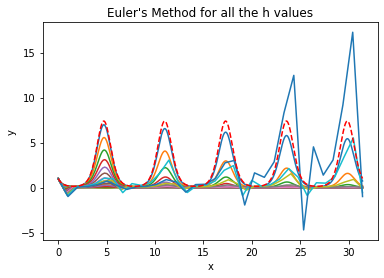

In [62]:
for h in h_arr:
    num_steps_2 = int((x_end - x_start) / h)

    x_values_2 = np.linspace(x_start, x_end, num_steps_2 + 1)
    y_values_2 = np.zeros(num_steps_2 + 1)


    # Initial condition
    y_values_2[0] = 1  # y(0) = 1


    # Implement Euler's method

    for i in range(num_steps_2):

        y_values_2[i + 1] = y_values_2[i] + h * f(x_values_2[i], y_values_2[i])
    
    plt.plot(x_values_2,y_values_2)

x_exact = np.linspace(x_start,x_end,10000)
plt.plot(x_exact, exact_solution(x_exact), "r--", label = "true solution")
plt.title("Euler's Method for all the h values")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

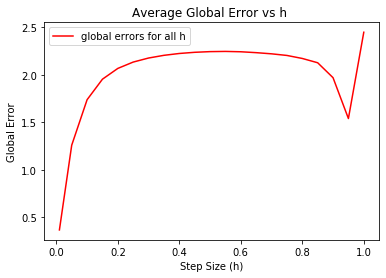

In [61]:
plt.plot(h_arr,np.array(errors_average), color = "red", label = "global errors for all h")
plt.title("Average Global Error vs h ")
plt.xlabel("Step Size (h)")
plt.ylabel("Global Error")
plt.legend()
plt.show()

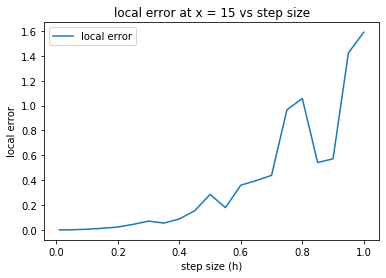

In [59]:
plt.plot(h_arr, specific_error, label = "local error")
plt.title("local error at x = 15 vs step size")
plt.xlabel("step size (h)")
plt.ylabel("local error")
plt.legend()
plt.show()

When the stepsize is small, the Euler approximation seems to track the original function quite well. This is because the Euler method can readjust slopes at a much more frequent rate, allowing for the slope at each point to be much more accurate. With an increasing h value, the solution begins to diverge and have erratic behavior. Large step sizes means that the true slope is used at lesser points and the method is forced to display the "in-between" as a linear function when the true nature of the solution is exponential. The average global error seems to be growing with a logarithmic pattern until some weird deviations at the end. This would make sense as the method does a worse job of representing the function with an increasing h-value. This subsequently would mean the average global error increases. Even the local error at x = 15 is generally increasing as step size increases although there are some deviations from this. 